In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:

# Wektor wartości k od 0 do 16
k_vals = np.arange(17)
# Wektor wartości x = 10^-k
x_vals = 10.0**(-k_vals)

In [3]:

def f_original(x):
    return np.where(x == 0, 1.0, (np.exp(x) - 1) / x)

def f_kahan(x):
    y = np.exp(x)
    # Jeśli y = 1 (z powodu braku precyzji), zwracamy 1, w przeciwnym razie wzór
    return np.where(y == 1.0, 1.0, (y - 1) / np.log(y))

# e^x - 1 = x + x^2/2! + x^3/3! + ...
# (e^x - 1)/x = 1 + x/2 + x^2/6 + ...
def f_taylor(x):
    return 1.0 + x/2.0 + (x**2)/6.0

def f_expm1(x):
    return np.where(x == 0, 1.0, np.expm1(x) / x)

In [6]:

y_original = f_original(x_vals)
y_kahan = f_kahan(x_vals)
y_taylor = f_taylor(x_vals)
y_expm1 = f_expm1(x_vals)

C:\Users\julia\AppData\Local\Temp\ipykernel_13056\1826026772.py:7: RuntimeWarning: invalid value encountered in divide
  return np.where(y == 1.0, 1.0, (y - 1) / np.log(y))


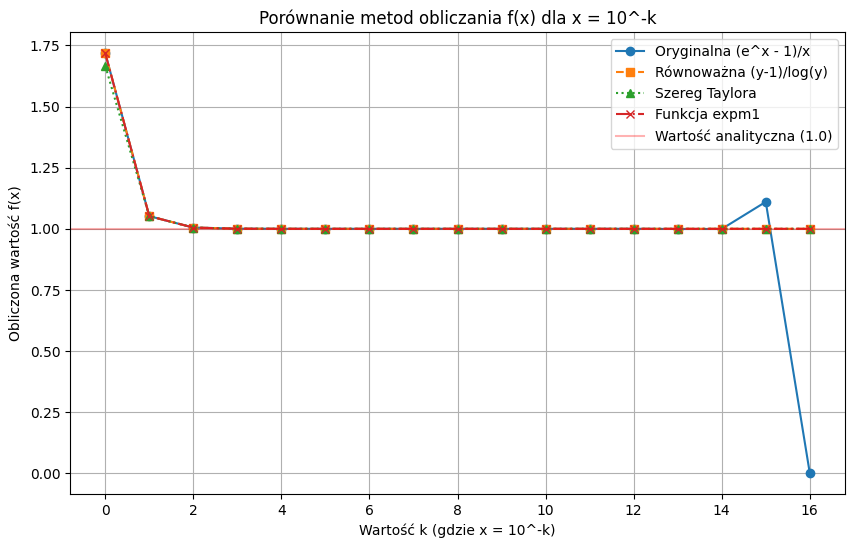

In [5]:

plt.figure(figsize=(10, 6))

plt.plot(k_vals, y_original, 'o-', label='Oryginalna (e^x - 1)/x')
plt.plot(k_vals, y_kahan, 's--', label='Równoważna (y-1)/log(y)')
plt.plot(k_vals, y_taylor, '^:', label='Szereg Taylora')
plt.plot(k_vals, y_expm1, 'x-.', label='Funkcja expm1')

plt.axhline(y=1.0, color='r', linestyle='-', alpha=0.3, label='Wartość analityczna (1.0)')

plt.title('Porównanie metod obliczania f(x) dla x = 10^-k')
plt.xlabel('Wartość k (gdzie x = 10^-k)')
plt.ylabel('Obliczona wartość f(x)')
plt.legend()
plt.grid(True)
plt.show()